## Data Preparation

In [7]:
!pip install dlib

In [8]:
import os 
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Flatten, TimeDistributed, LSTM, Dropout
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import dlib
from tensorflow.keras.applications import MobileNet, ResNet50, Xception 
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Input, Dense
from tensorflow.keras.models import Model


### 1. CÁC THAM SỐ CẤU HÌNH ###
REAL_PATH = "/kaggle/input/ff-c23/FaceForensics++_C23/original"
FAKE_PATH = "/kaggle/input/ff-c23/FaceForensics++_C23/Deepfakes"
OUTPUT_FRAME_SIZE = (224, 224)
FRAME_COUNT = 15
MAX_VIDEOS = 200
BATCH_SIZE = 8
PADDING_FACTOR = 1.3
LR_FINE_TUNE = 1e-6 # Learning Rate ban đầu cho Fine-Tuning

In [ ]:
print(f"Số lượng file trong thư mục REAL: {len(os.listdir(REAL_PATH))}")
print(f"Số lượng file trong thư mục FAKE: {len(os.listdir(FAKE_PATH))}")

In [10]:
face_detector_dlib = dlib.get_frontal_face_detector() 
def extract_frames(video_path, output_size=OUTPUT_FRAME_SIZE, frame_count=FRAME_COUNT, padding_factor=1.3):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return np.array([])

    step = max(total_frames // frame_count, 1)

    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_detector_dlib(gray)
        
        frame_h, frame_w, _ = frame.shape # Kích thước khung hình gốc

        if len(faces) > 0:
            d = faces[0]
            
            # Tính toán tâm và kích thước khuôn mặt
            y_center, x_center = (d.top() + d.bottom()) // 2, (d.left() + d.right()) // 2
            h, w = d.bottom() - d.top(), d.right() - d.left()
            
            # Tính toán cắt bảo thủ (Conservative Cropping)
            h_pad, w_pad = int(h * padding_factor), int(w * padding_factor)
            
            # Xác định tọa độ cắt mới (tránh lỗi out-of-bound)
            y1 = max(0, y_center - h_pad // 2)
            y2 = min(frame_h, y_center + h_pad // 2)
            x1 = max(0, x_center - w_pad // 2)
            x2 = min(frame_w, x_center + w_pad // 2)
            
            cropped_face = frame[y1:y2, x1:x2]
            
            if cropped_face.size != 0:
                resized_frame = cv2.resize(cropped_face, output_size)
                frames.append(resized_frame)
                continue # Đã tìm thấy và cắt thành công
        
        # Nếu Dlib không tìm thấy hoặc cắt lỗi, resize toàn frame
        resized_frame = cv2.resize(frame, output_size)
        frames.append(resized_frame)

    cap.release()
    return np.array(frames) if len(frames) == frame_count else np.array([])

In [ ]:
# --- PHẦN THỰC THI (TẠO BIẾN DỮ LIỆU) ---

# Tải dữ liệu và phân chia (Giữ nguyên logic phân chia 70/15/15)
data, labels = [], []

print(f"Bắt đầu tải tối đa {MAX_VIDEOS} video REAL...")
for video_file in os.listdir(REAL_PATH)[:MAX_VIDEOS]:
    frames = extract_frames(os.path.join(REAL_PATH, video_file))
    if frames.size != 0: data.append(frames); labels.append(0)

print(f"Bắt đầu tải tối đa {MAX_VIDEOS} video FAKE...")
for video_file in os.listdir(FAKE_PATH)[:MAX_VIDEOS]:
    frames = extract_frames(os.path.join(FAKE_PATH, video_file))
    if frames.size != 0: data.append(frames); labels.append(1)

print(f"Tổng số video đã tải thành công: {len(data)}")

# Chuyển đổi và phân chia tập dữ liệu (Tạo ra X_train, X_val, X_test)
data = np.array(data); labels = np.array(labels)

# Phân chia 70% Training / 30% Tạm thời
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)

# Phân chia 30% Tạm thời thành 15% Validation / 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Chuẩn hóa dữ liệu pixel (đã được nhân tiện ở các ô trước đó)
X_train = X_train / 255.0; X_val = X_val / 255.0; X_test = X_test / 255.0

# Mã hóa nhãn (One-hot encoding)
y_train_cat = to_categorical(y_train, num_classes=2)
y_val_cat = to_categorical(y_val, num_classes=2)

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# --- CẤU HÌNH ĐƯỜNG DẪN VIDEO CỤ THỂ ---
# Đây là hai video bạn đã xác định:
REAL_VIDEO_PATH = "/kaggle/input/ff-c23/FaceForensics++_C23/original/012.mp4"
FAKE_VIDEO_PATH = "/kaggle/input/ff-c23/FaceForensics++_C23/Deepfakes/012_026.mp4"

def illustrate_specific_comparison(real_path, fake_path):
    print(f"🔄 Đang xử lý so sánh video...")
    print(f"   - Real: {real_path}")
    print(f"   - Fake: {fake_path}")

    # Kiểm tra tồn tại
    if not os.path.exists(real_path):
        print(f"❌ Lỗi: Không tìm thấy video REAL tại: {real_path}")
        return
    if not os.path.exists(fake_path):
        print(f"❌ Lỗi: Không tìm thấy video FAKE tại: {fake_path}")
        return

    # Hàm lấy frame
    def get_frame(video_path):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0: return None
        
        # Lấy frame ở 50% thời lượng để đảm bảo có mặt
        target_frame = total_frames // 2
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        cap.release()
        
        if ret:
            # Chuyển từ BGR sang RGB để hiển thị đúng màu
            return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return None

    # Lấy frame
    img_real = get_frame(real_path)
    img_fake = get_frame(fake_path)

    if img_real is None or img_fake is None:
        print("❌ Lỗi: Không thể đọc frame từ video (file có thể bị hỏng hoặc không có quyền truy cập).")
        return

    # Vẽ hình so sánh
    plt.figure(figsize=(16, 8))

    # Ảnh Real
    plt.subplot(1, 2, 1)
    plt.imshow(img_real)
    plt.title(f"VIDEO GỐC (REAL)\n{os.path.basename(real_path)}", color='green', fontsize=14, fontweight='bold')
    plt.axis('off')

    # Ảnh Fake
    plt.subplot(1, 2, 2)
    plt.imshow(img_fake)
    plt.title(f"VIDEO GIẢ MẠO (DEEPFAKE)\n{os.path.basename(fake_path)}", color='red', fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    print("✅ Đã tạo hình minh họa thành công.")

# --- CHẠY HÀM ---
illustrate_specific_comparison(REAL_VIDEO_PATH, FAKE_VIDEO_PATH)

In [ ]:
import cv2
import matplotlib.pyplot as plt
import dlib

# Load bộ phát hiện khuôn mặt
detector = dlib.get_frontal_face_detector()

# Đọc 1 frame từ video bất kỳ
video_path = "/kaggle/input/ff-c23/FaceForensics++_C23/original/000.mp4" # Thay đường dẫn video của bạn
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)
    
    # Vẽ hình chữ nhật quanh mặt trên bản sao của frame gốc
    frame_vis = frame.copy()
    for face in faces:
        x, y = face.left(), face.top()
        w, h = face.width(), face.height()
        cv2.rectangle(frame_vis, (x, y), (x+w, y+h), (0, 255, 0), 10) # Tăng độ dày viền lên 10 để dễ thấy
    
    # Hiển thị toàn bộ khung hình với bounding box
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
    plt.title("Face Extraction Process (Full Frame with Bounding Box)")
    plt.axis('off')
    plt.show()

## Data Augmentation

In [ ]:
### 3. DATA GENERATOR (Không thay đổi) ###
datagen = ImageDataGenerator(horizontal_flip=True, rotation_range=15, zoom_range=0.15)
class VideoDataGenerator(Sequence):
    def __init__(self, x_set, y_set, batch_size, augmentations=None):
        self.x, self.y = x_set, y_set; self.batch_size = batch_size; self.augment = augmentations
    def __len__(self): return int(np.ceil(len(self.x) / self.batch_size))
    def __getitem__(self, idx):
        indices = np.arange(idx * self.batch_size, min((idx + 1) * self.batch_size, len(self.x)))
        batch_x, batch_y = self.x[indices], self.y[indices]
        if self.augment: return np.array([self.augment_video(video) for video in batch_x]), batch_y
        return batch_x, batch_y
    def augment_video(self, video_frames): return np.array([self.augment.random_transform(frame) for frame in video_frames])
train_generator = VideoDataGenerator(X_train, y_train_cat, BATCH_SIZE, datagen)
validation_generator = VideoDataGenerator(X_val, y_val_cat, BATCH_SIZE)

In [ ]:
### 4. XÂY DỰNG MODEL (Tinh chỉnh Dropout) ###
def build_finetune_model(input_shape=(FRAME_COUNT, 224, 224, 3)):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False 
    model = Sequential([
        TimeDistributed(base_model, input_shape=input_shape),
        TimeDistributed(Flatten()),
        Dropout(0.4), # ### FIX: Giảm nhẹ Dropout
        LSTM(128, return_sequences=False),
        Dropout(0.4), # ### FIX: Giảm nhẹ Dropout
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])
    return model
model = build_finetune_model()

## Model Architecture

In [ ]:
### 5. HUẤN LUYỆN MODEL (Thêm Class Weight và tinh chỉnh Fine-Tuning) ###
# ### NEW: Tính toán Class Weight để xử lý mất cân bằng
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights to balance data: {class_weight_dict}")

callbacks = [
    ModelCheckpoint(
        "best_model.keras", 
        monitor="val_accuracy",
        save_best_only=True, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", 
        factor=0.2, 
        patience=3,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        verbose=1,
        restore_best_weights=True
    )
]

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights)) # <--- DÒNG NÀY TẠO RA BIẾN BỊ LỖI
print(f"Class Weights to balance data: {class_weight_dict}")

## Model Training

In [ ]:
# --- GIAI ĐOẠN 1: Huấn luyện với Class Weight ---
print("--- PHASE 1: Training Top Layers with Class Weights---")
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_top = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20, # Tăng epoch cho giai đoạn đầu
    callbacks=callbacks,
    class_weight=class_weight_dict # ### NEW: Áp dụng class weight
)

# --- GIAI ĐOẠN 2: Tinh chỉnh (Fine-tuning) an toàn hơn ---
print("\n--- PHASE 2: Fine-tuning ---")
# Mở băng base model
model.layers[0].layer.trainable = True

# ### NEW: Giữ các lớp BatchNormalization bị đóng băng để ổn định
for layer in model.layers[0].layer.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Mở băng một phần nhỏ các lớp cuối
for layer in model.layers[0].layer.layers[:-20]:
   layer.trainable = False

# Compile lại với learning rate siêu nhỏ
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=60, # Tăng số epoch tối đa (EarlyStopping sẽ tự dừng)
    initial_epoch=history_top.epoch[-1],
    callbacks=callbacks,
    class_weight=class_weight_dict
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# --- 1. IMPORT ĐẦY ĐỦ CÁC THƯ VIỆN CẦN THIẾT ---
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Input
from tensorflow.keras.applications import ResNet50, MobileNet, Xception
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

# --- CẤU HÌNH ---
THRESHOLD_OPTIMAL = 0.5
EPOCHS_BASELINE = 10
BATCH_SIZE = 8

print(" BẮT ĐẦU QUY TRÌNH SO SÁNH MÔ HÌNH (MỤC 4.4)...\n")

# ==============================================================================
# BƯỚC 1: LẤY KẾT QUẢ MÔ HÌNH ĐỀ XUẤT (XCEPTION-LSTM)
# ==============================================================================
print("--- 1. Thu thập kết quả Mô hình Đề xuất (Xception-LSTM) ---")

# Kiểm tra dữ liệu đầu vào
if 'X_test' not in locals() or 'y_test' not in locals():
    raise ValueError("❌ LỖI: Không tìm thấy dữ liệu X_test/y_test. Vui lòng chạy lại Ô 2!")

# Tải model tốt nhất hoặc dùng model hiện tại
try:
    best_model = load_model('/kaggle/working/best_model.keras')
    print("   -> Đã tải model từ file 'best_model.keras'.")
except:
    print("   ->  Không tìm thấy file. Đang dùng biến 'model' hiện tại.")
    best_model = model 

# Dự đoán lại
y_pred_lstm = best_model.predict(X_test, verbose=0)
y_pred_classes_lstm = (y_pred_lstm[:, 1] > THRESHOLD_OPTIMAL).astype(int)
y_true = y_test 

# Tính Metrics cho Xception-LSTM
metrics_lstm = {
    'Model': 'Xception-LSTM (Đề xuất)',
    'Accuracy': accuracy_score(y_true, y_pred_classes_lstm) * 100,
    'Precision': precision_score(y_true, y_pred_classes_lstm, pos_label=1) * 100,
    'Recall': recall_score(y_true, y_pred_classes_lstm, pos_label=1) * 100,
    'Specificity': recall_score(y_true, y_pred_classes_lstm, pos_label=0) * 100,
    'AUC': roc_auc_score(y_true, y_pred_lstm[:, 1]) * 100 # Nhân 100 cho AUC
}
print(f"   -> Kết quả Đề xuất: Accuracy={metrics_lstm['Accuracy']:.2f}%, Recall={metrics_lstm['Recall']:.2f}%")


# ==============================================================================
# BƯỚC 2: HUẤN LUYỆN CÁC MÔ HÌNH SO SÁNH (BASELINES)
# ==============================================================================
print("\n--- 2. Huấn luyện Mô hình So sánh (Spatial Only) ---")

def prepare_static_data(X_video, y_labels):
    N_videos, N_frames = X_video.shape[:2]
    X_flat = X_video.reshape(N_videos * N_frames, *X_video.shape[2:])
    y_flat = np.repeat(y_labels, N_frames)
    return X_flat, y_flat

if 'X_train_flat' not in locals():
    print("   -> Đang chuyển đổi dữ liệu sang khung hình tĩnh...")
    X_train_flat, y_train_flat = prepare_static_data(X_train, y_train)
    X_val_flat, y_val_flat = prepare_static_data(X_val, y_val)
    X_test_flat, y_test_flat = prepare_static_data(X_test, y_test)

    y_train_flat_cat = to_categorical(y_train_flat, 2)
    y_val_flat_cat = to_categorical(y_val_flat, 2)
    y_train_flat_int = y_train_flat.astype(int)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_flat_int), y=y_train_flat_int)
    cw_dict = dict(enumerate(class_weights))
else:
    print("   -> Dữ liệu tĩnh đã có sẵn.")

def build_baseline_cnn(base_cnn_class):
    input_tensor = Input(shape=(224, 224, 3)) 
    base_model = base_cnn_class(weights='imagenet', include_top=False, input_tensor=input_tensor)
    base_model.trainable = False 
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    output = Dense(2, activation='softmax')(x)
    return Model(inputs=input_tensor, outputs=output)

baseline_results = [metrics_lstm] 
baselines = [
    ('MobileNet', MobileNet), 
    ('ResNet50', ResNet50), 
    ('XceptionNet (Tĩnh)', Xception)
]

for name, base_class in baselines:
    print(f"\n   >> Đang huấn luyện {name}...")
    model_bl = build_baseline_cnn(base_class)
    model_bl.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_bl.fit(X_train_flat, y_train_flat_cat, 
                 validation_data=(X_val_flat, y_val_flat_cat),
                 epochs=EPOCHS_BASELINE, batch_size=16, 
                 class_weight=cw_dict, verbose=0)
    
    y_prob = model_bl.predict(X_test_flat, verbose=0)
    y_cls = np.argmax(y_prob, axis=1)
    
    res = {
        'Model': name,
        'Accuracy': accuracy_score(y_test_flat, y_cls) * 100,
        'Precision': precision_score(y_test_flat, y_cls, pos_label=1) * 100,
        'Recall': recall_score(y_test_flat, y_cls, pos_label=1) * 100,
        'Specificity': recall_score(y_test_flat, y_cls, pos_label=0) * 100,
        'AUC': roc_auc_score(y_test_flat, y_prob[:, 1]) * 100 # Nhân 100 cho AUC
    }
    baseline_results.append(res)
    print(f"      -> Xong. Acc: {res['Accuracy']:.2f}%, AUC: {res['AUC']:.2f}")


# ==============================================================================
# BƯỚC 3: TỔNG HỢP VÀ VẼ BIỂU ĐỒ (FIX LỖI HIỂN THỊ & MÀU SẮC)
# ==============================================================================
print("\n--- 3. Vẽ Biểu Đồ So Sánh ---")
df_final = pd.DataFrame(baseline_results)
df_final = df_final.set_index('Model').sort_values(by='Accuracy', ascending=False)

print("\nBẢNG KẾT QUẢ (Copy vào báo cáo):")
print(df_final.round(2))

# Fix lỗi: .reset_index() trước khi melt
df_melted = df_final.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')
# Thêm Specificity vào danh sách vẽ biểu đồ
metrics_to_plot = ['Accuracy', 'Recall', 'Precision', 'Specificity', 'AUC']
df_plot = df_melted[df_melted['Metric'].isin(metrics_to_plot)]

plt.figure(figsize=(14, 7)) # Tăng chiều rộng
# Đổi bảng màu sang 'tab10' để dễ phân biệt
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='tab10', edgecolor='black')

plt.title('So sánh Hiệu suất: Xception-LSTM (Đề xuất) vs Các Mô hình Nền tảng', fontsize=14, fontweight='bold')
plt.ylabel('Giá trị (%) / AUC (x100)', fontsize=12)
plt.ylim(0, 135) # Tăng giới hạn Y để chừa chỗ cho chú thích

# Di chuyển chú thích ra vị trí thoáng và dễ đọc
plt.legend(title='Mô hình', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CHUẨN BỊ DỮ LIỆU (FIX LỖI KEYERROR) ---

# Reset index để đưa 'Model' từ Index trở lại thành Cột
df_reset = df_final.reset_index()

# Đổi tên cột index thành 'Model' nếu cần thiết (đề phòng trường hợp tên index bị mất)
if 'Model' not in df_reset.columns:
    df_reset = df_reset.rename(columns={'index': 'Model'})

# Chuyển đổi dữ liệu sang định dạng 'dài' (melt)
df_final_melted = df_reset.melt(
    id_vars='Model', 
    var_name='Metric', 
    value_name='Score'
)

# Lọc các chỉ số cần vẽ
metrics_to_plot = ['Accuracy', 'Recall', 'Precision', 'AUC']
df_plot = df_final_melted[df_final_melted['Metric'].isin(metrics_to_plot)]

# --- 2. VẼ BIỂU ĐỒ CỘT SO SÁNH ---

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette='viridis' # Bảng màu đẹp và rõ ràng
)

# Đặt tiêu đề và nhãn
plt.title('Biểu đồ so sánh số liệu của các mô hình khác nhau', fontsize=14)
plt.ylabel('Giá trị (%) / AUC', fontsize=12)
plt.xlabel('Chỉ số Đánh giá', fontsize=12)
plt.ylim(0, 115) # Mở rộng trục Y để chừa chỗ cho chú thích

# Lưới ngang để dễ nhìn
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- FIX: Di chuyển Bảng chú thích (Legend) ra ngoài ---
plt.legend(title='Model', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Evaluating Final Model ---")
# Tải model tốt nhất đã được lưu bởi checkpoint
best_model = load_model('best_model.keras')

In [ ]:
### 7. ĐÁNH GIÁ MODEL ###
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
# NEW: Hàm tính Specificity
def calculate_specificity(y_true_labels, y_pred_classes):
    cm = confusion_matrix(y_true_labels, y_pred_classes)
    # TN (Real -> Real) ở [0, 0], FP (Real -> Fake) ở [0, 1]
    TN = cm[0, 0]
    FP = cm[0, 1]
    if (TN + FP) == 0:
        return 0.0
    return TN / (TN + FP)
print("\n--- Evaluating Final Model (Restored from best epoch) ---")
# 'restore_best_weights=True' trong EarlyStopping đã khôi phục model tốt nhất.
# Hoặc tải từ checkpoint để chắc chắn:
try:
    best_model = load_model('/kaggle/working/best_model.keras')
    print("Model tốt nhất đã được tải từ 'best_model.keras'.")
except Exception as e:
    print(f"Không thể tải 'best_model.keras', sử dụng model hiện tại. Lỗi: {e}")
    best_model = model # Dùng model cuối cùng nếu tải lỗi

# Đánh giá trên tập test
y_pred = best_model.predict(X_test)
THRESHOLD_OPTIMAL = 0.5
y_pred_classes = (y_pred[:, 1] > THRESHOLD_OPTIMAL).astype(int)
y_true = y_test # Sử dụng y_test (nhãn số nguyên)

# Metrics
accuracy = accuracy_score(y_true, y_pred_classes)
specificity_score = calculate_specificity(y_true, y_pred_classes) # NEW: Tính Specificity

print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")
print(f"Specificity (Độ Đặc hiệu): {specificity_score * 100:.2f}%") # NEW: In Specificity
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['REAL', 'FAKE']))

In [ ]:
from sklearn.metrics import recall_score, precision_score, accuracy_score
import numpy as np

# Các ngưỡng cần thử (Bắt đầu từ 0.5 và giảm dần)
THRESHOLDS = [0.5, 0.45, 0.40, 0.35, 0.30] 

# y_pred là xác suất thô từ model.predict(X_test)
# y_test là nhãn thật (y_true)

print("--- PHÂN TÍCH HIỆU SUẤT THEO NGƯỠNG PHÂN LOẠI ---")
print("Ngưỡng | Accuracy | Recall (FAKE) | Precision (FAKE) | F1-Score")
print("----------------------------------------------------------------")

for threshold in THRESHOLDS:
    # 1. Áp dụng ngưỡng mới: Xác suất FAKE > threshold -> FAKE (1)
    # y_pred[:, 1] là xác suất FAKE
    y_pred_thresholded = (y_pred[:, 1] > threshold).astype(int)
    
    # 2. Tính toán lại chỉ số
    acc = accuracy_score(y_test, y_pred_thresholded)
    
    # Tính Precision/Recall/F1 cho lớp FAKE (pos_label=1)
    recall_fake = recall_score(y_test, y_pred_thresholded, pos_label=1, zero_division=0)
    precision_fake = precision_score(y_test, y_pred_thresholded, pos_label=1, zero_division=0)
    
    # Tính F1-Score (Trung bình điều hòa của Precision và Recall)
    if (precision_fake + recall_fake) == 0:
        f1_score = 0.0
    else:
        f1_score = 2 * (precision_fake * recall_fake) / (precision_fake + recall_fake)
    
    print(f"{threshold:.2f}  | {acc:.4f}   | {recall_fake:.4f}     | {precision_fake:.4f}       | {f1_score:.4f}")

## Model Testing

In [ ]:
### 8. VẼ BIỂU ĐỒ ###

# Hàm vẽ lịch sử
def plot_training_history(history_dict):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_dict['accuracy'], label='Train Accuracy')
    plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history_dict['loss'], label='Train Loss')
    plt.plot(history_dict['val_loss'], label='Validation Loss')
    plt.title('Model Loss over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout(); plt.show()

# Hàm vẽ ma trận nhầm lẫn
def plot_confusion_matrix(y_true_labels, y_pred_classes):
    cm = confusion_matrix(y_true_labels, y_pred_classes)
    cm_labels = ['Real', 'Fake']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
    plt.title('Confusion Matrix'); plt.xlabel('Predicted Labels'); plt.ylabel('True Labels'); plt.show()
# NEW: Hàm vẽ ROC Curve
def plot_roc_curve(y_true_labels, y_pred_proba):
    # Tính toán ROC Curve (FPR, TPR)
    fpr, tpr, thresholds = roc_curve(y_true_labels, y_pred_proba)
    # Tính toán AUC Score
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường đoán ngẫu nhiên
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)'); plt.ylabel('True Positive Rate (TPR) / Recall')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right"); 
    plt.show()
# Kết hợp lịch sử từ hai giai đoạn
combined_history = {
    'accuracy': history_top.history['accuracy'] + history_finetune.history['accuracy'],
    'val_accuracy': history_top.history['val_accuracy'] + history_finetune.history['val_accuracy'],
    'loss': history_top.history['loss'] + history_finetune.history['loss'],
    'val_loss': history_top.history['val_loss'] + history_finetune.history['val_loss']
}

print("\n--- Training History ---")
plot_training_history(combined_history)

print("\n--- Confusion Matrix ---")
plot_confusion_matrix(y_test, y_pred_classes)

y_pred_proba_fake = y_pred[:, 1] 

print("\n--- ROC Curve & AUC Score ---")
plot_roc_curve(y_test, y_pred_proba_fake)

Model đã được tải thành công từ: /kaggle/input/d/tensorflow2/default/1/best_model.keras

--- Dự đoán Video Thật ---
--- Đang phân tích video: 201.mp4 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


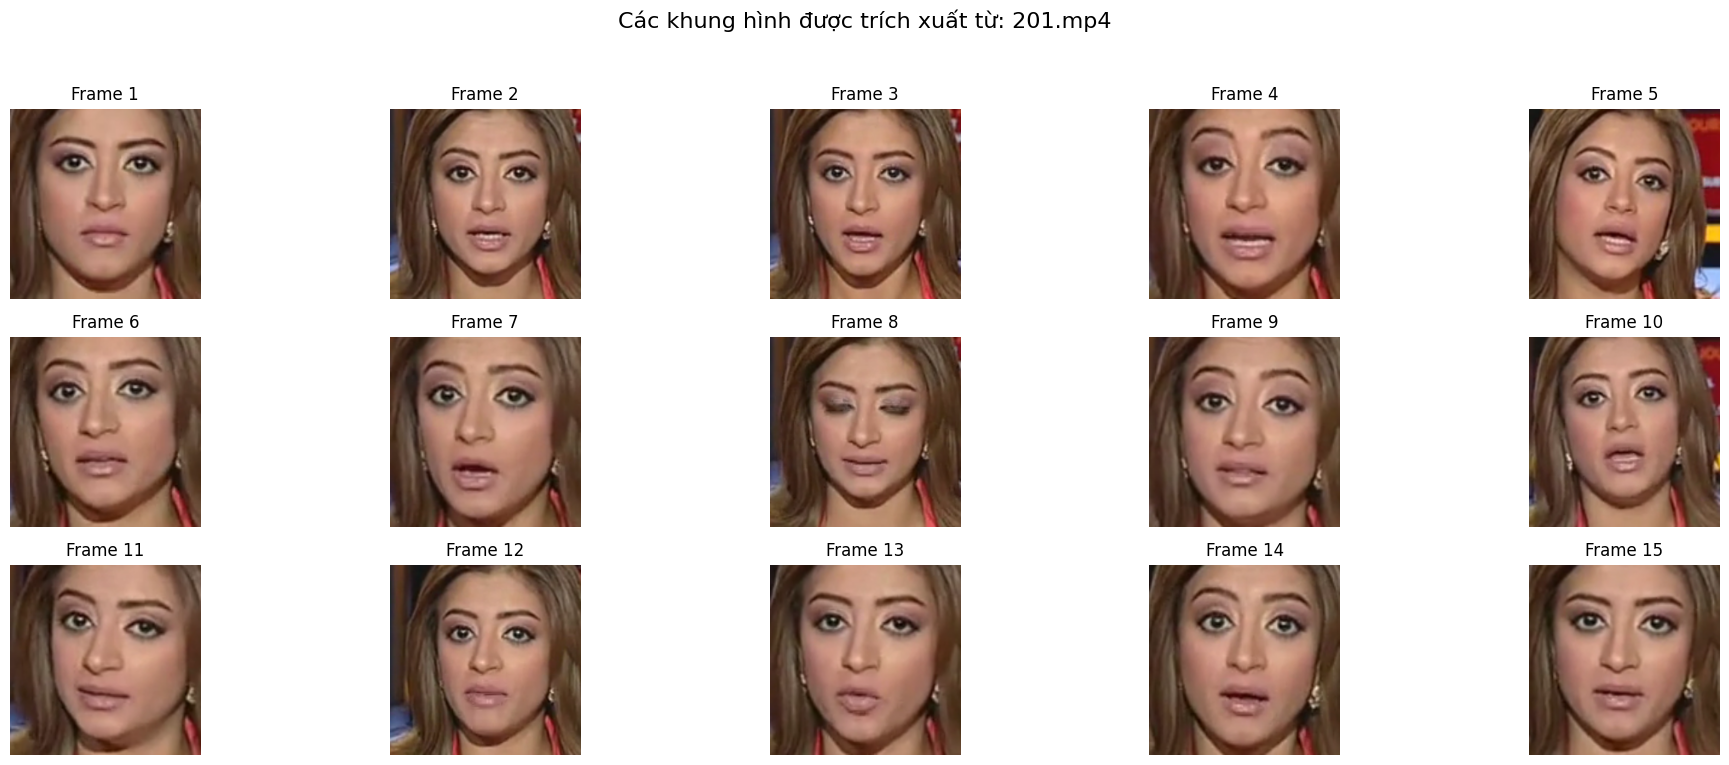


==> KẾT QUẢ TỔNG HỢP (Ngưỡng 0.5): REAL (Độ tin cậy: 59.63%)

--- Dự đoán Video Giả mạo ---
--- Đang phân tích video: 201_203.mp4 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


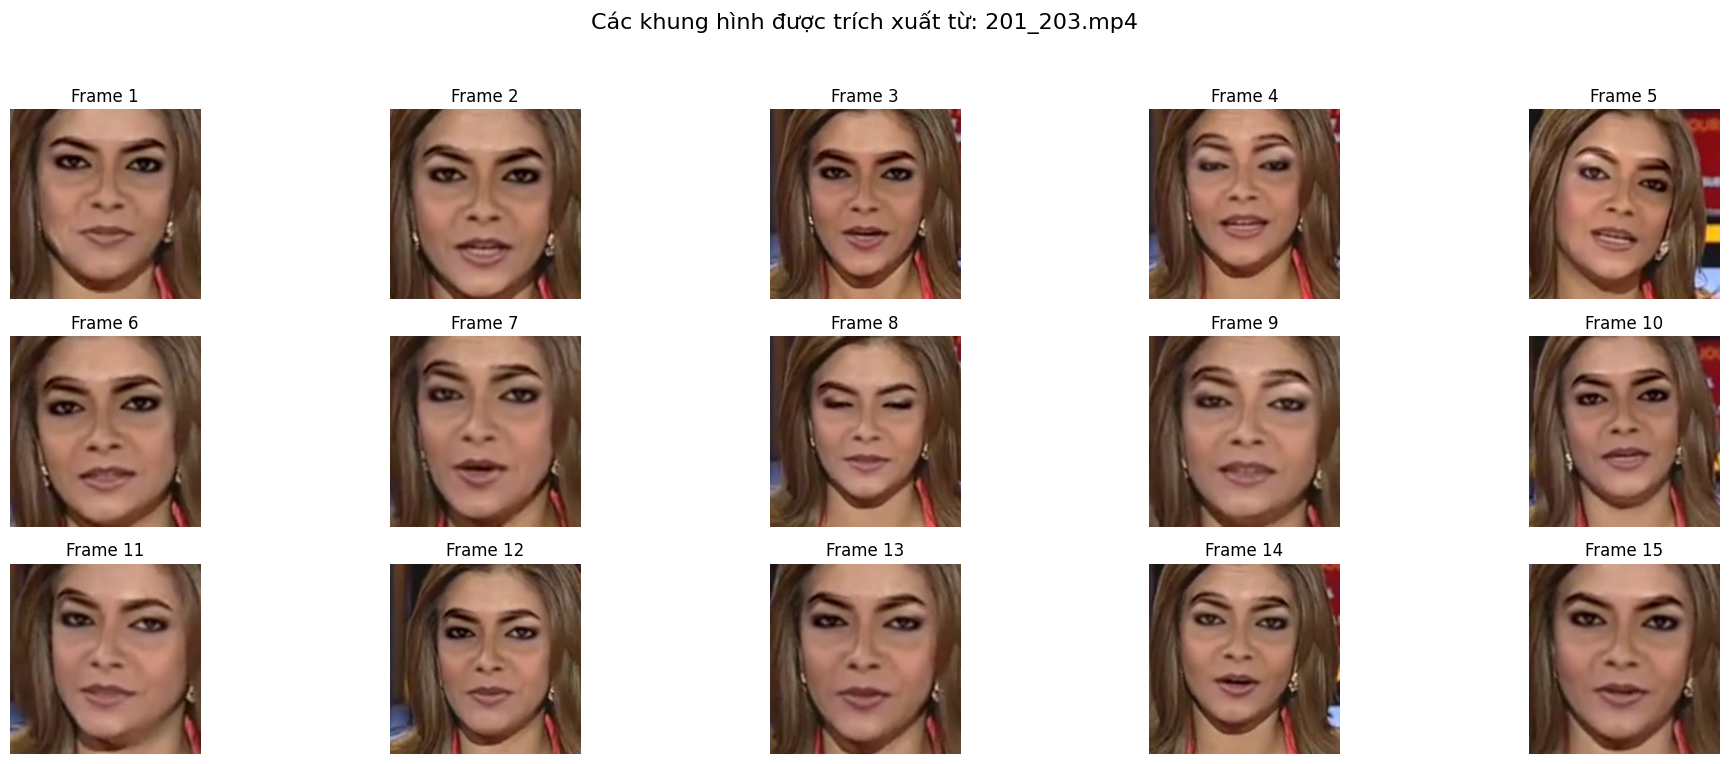


==> KẾT QUẢ TỔNG HỢP (Ngưỡng 0.5): FAKE (Độ tin cậy: 58.14%)


In [17]:
### 9. TRỰC QUAN HÓA DỰ ĐOÁN (ÁP DỤNG NGƯỠNG 0.35 ĐÃ SỬA LỖI) ###

from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Tải model tốt nhất
try:
    model_path = '/kaggle/input/d/tensorflow2/default/1/best_model.keras'
    best_model = load_model(model_path)
    print(f"Model đã được tải thành công từ: {model_path}")
except Exception as e:
    print(f"LỖI: Không tìm thấy tệp model tại '{model_path}'.")
    best_model = None

# Hàm dự đoán và trực quan hóa (ĐÃ SỬA LỖI)
def predict_and_visualize_frames(video_path, full_model):
    if full_model is None:
        print("Mô hình chưa được tải, không thể dự đoán.")
        return

    print(f"--- Đang phân tích video: {video_path.split('/')[-1]} ---")
    
    # 1. Trích xuất khung hình
    frames = extract_frames(
        video_path, 
        output_size=OUTPUT_FRAME_SIZE,
        frame_count=FRAME_COUNT
    )
    
    if frames.size == 0:
        print(f"Không thể trích xuất khung hình hoặc không tìm thấy khuôn mặt.")
        return

    # 2. Chuẩn bị dữ liệu và Dự đoán
    processed_frames = frames / 255.0
    full_sequence_batch = np.expand_dims(processed_frames, axis=0)
    full_prediction = full_model.predict(full_sequence_batch)
    
    # --- LOGIC MỚI: ÁP DỤNG NGƯỠNG 0.5 ---
    THRESHOLD_RUNTIME = 0.5
    prob_fake = full_prediction[0][1] # Xác suất FAKE (cột 1)
    
    if prob_fake >= THRESHOLD_RUNTIME:
        label = "FAKE"
        # Độ tin cậy là xác suất FAKE
        confidence = prob_fake 
    else:
        label = "REAL"
        # Độ tin cậy là xác suất REAL (1 - prob_fake)
        confidence = full_prediction[0][0] 

    # 3. Trực quan hóa khung hình
    plt.figure(figsize=(20, 8))
    # Sử dụng logic 3 hàng, 5 cột (3, 5) để khớp với FRAME_COUNT=15
    plt.suptitle(f"Các khung hình được trích xuất từ: {video_path.split('/')[-1]}", fontsize=16)
    
    for i in range(FRAME_COUNT):
        ax = plt.subplot(3, 5, i + 1) # Sử dụng 3 hàng, 5 cột
        frame_rgb = cv2.cvtColor(frames[i].astype('uint8'), cv2.COLOR_BGR2RGB)
        plt.imshow(frame_rgb)
        plt.title(f"Frame {i+1}"); plt.axis('off')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # 4. In kết quả cuối cùng
    print(f"\n==> KẾT QUẢ TỔNG HỢP (Ngưỡng {THRESHOLD_RUNTIME}): {label} (Độ tin cậy: {confidence * 100:.2f}%)")

# --- CHẠY DỰ ĐOÁN ---
real_sample_path = "/kaggle/input/ff-c23/FaceForensics++_C23/original/201.mp4"
fake_sample_path = "/kaggle/input/ff-c23/FaceForensics++_C23/Deepfakes/201_203.mp4"

print("\n--- Dự đoán Video Thật ---")
predict_and_visualize_frames(real_sample_path, best_model)

print("\n--- Dự đoán Video Giả mạo ---")
predict_and_visualize_frames(fake_sample_path, best_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


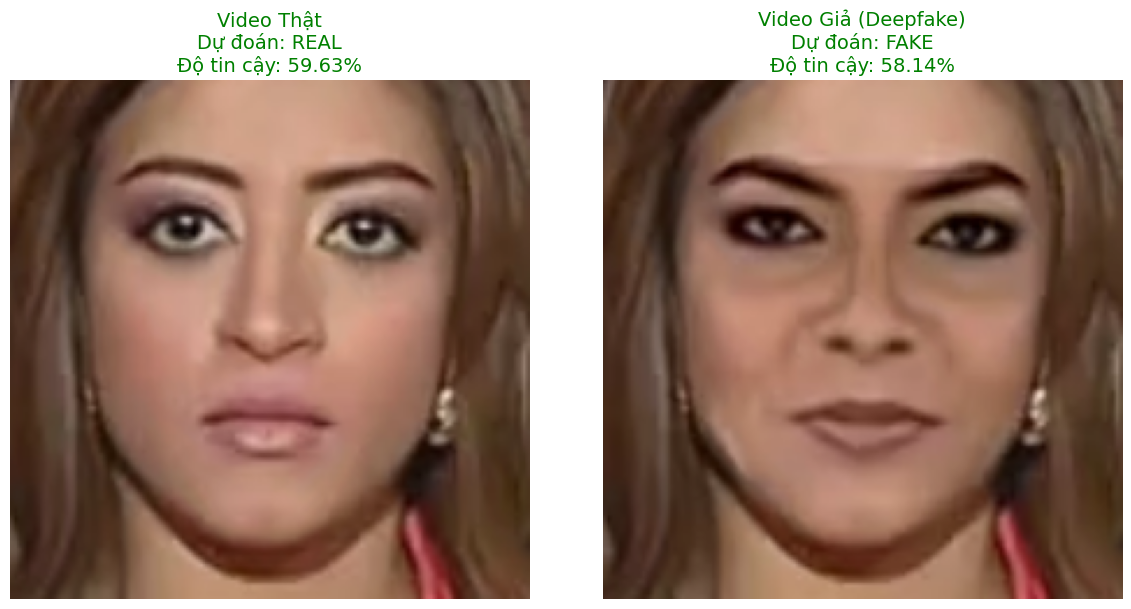

In [16]:
def visualize_model_comparison(real_video_path, fake_video_path, model):
    # 1. Dự đoán Video Thật
    frames_real = extract_frames(real_video_path, output_size=OUTPUT_FRAME_SIZE, frame_count=FRAME_COUNT)
    pred_real = model.predict(np.expand_dims(frames_real / 255.0, axis=0))[0]
    conf_real = pred_real[0] if pred_real[0] > pred_real[1] else pred_real[1]
    label_real = "REAL" if pred_real[0] > 0.5 else "FAKE" # Ngưỡng 0.35
    
    # 2. Dự đoán Video Giả
    frames_fake = extract_frames(fake_video_path, output_size=OUTPUT_FRAME_SIZE, frame_count=FRAME_COUNT)
    pred_fake = model.predict(np.expand_dims(frames_fake / 255.0, axis=0))[0]
    conf_fake = pred_fake[1] if pred_fake[1] > 0.5 else pred_fake[0]
    label_fake = "FAKE" if pred_fake[1] > 0.5 else "REAL"

    # 3. Vẽ hình so sánh
    plt.figure(figsize=(12, 6))
    
    # Hiển thị frame đầu tiên của Video Thật
    plt.subplot(1, 2, 1)
    if len(frames_real) > 0:
        plt.imshow(cv2.cvtColor(frames_real[0], cv2.COLOR_BGR2RGB))
        plt.title(f"Video Thật\nDự đoán: {label_real}\nĐộ tin cậy: {conf_real:.2%}", color='green' if label_real=='REAL' else 'red', fontsize=14)
        plt.axis('off')

    # Hiển thị frame đầu tiên của Video Giả
    plt.subplot(1, 2, 2)
    if len(frames_fake) > 0:
        plt.imshow(cv2.cvtColor(frames_fake[0], cv2.COLOR_BGR2RGB))
        plt.title(f"Video Giả (Deepfake)\nDự đoán: {label_fake}\nĐộ tin cậy: {conf_fake:.2%}", color='green' if label_fake=='FAKE' else 'red', fontsize=14)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Gọi hàm với đường dẫn video thực tế của bạn
real_vid = "/kaggle/input/ff-c23/FaceForensics++_C23/original/201.mp4"
fake_vid = "/kaggle/input/ff-c23/FaceForensics++_C23/Deepfakes/201_203.mp4"
visualize_model_comparison(real_vid, fake_vid, best_model)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_sampling_diagram(total_frames=150, num_selected=15):
    # Tạo khung hình
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # 1. Vẽ trục thời gian của toàn bộ video (đường màu xám)
    ax.plot([0, total_frames], [1, 1], color='#e0e0e0', linewidth=8, label='Toàn bộ thời lượng Video', zorder=1)
    
    # Tính bước nhảy (step) giống hệt logic trong code training của bạn
    step = total_frames // num_selected
    
    # Xác định vị trí các frame được chọn
    selected_indices = [i * step for i in range(num_selected)]
    
    # 2. Vẽ các điểm đánh dấu Frame được chọn (chấm tròn màu xanh)
    ax.scatter(selected_indices, [1]*len(selected_indices), color='#007acc', s=150, zorder=5, label='Khung hình được trích xuất (Input)')
    
    # 3. Vẽ các đường gióng và chú thích
    for i, idx in enumerate(selected_indices):
        # Vẽ đường gióng xuống
        ax.plot([idx, idx], [1, 0.6], color='#007acc', linestyle=':', linewidth=1.5)
        
        # Ghi số thứ tự Frame (chỉ ghi một vài số để đỡ rối)
        if i == 0 or i == num_selected-1 or i % 2 == 0:
            ax.text(idx, 0.5, f'F{i+1}\n({idx})', ha='center', va='top', fontsize=9, color='#333333', fontweight='bold')

    # Trang trí biểu đồ
    ax.set_xlim(-5, total_frames + 5)
    ax.set_ylim(0.4, 1.4)
    ax.set_title(f'Minh họa chiến lược "Lấy mẫu đều theo thời gian" (Uniform Sampling)\nTổng: {total_frames} frames | Chọn: {num_selected} frames | Bước nhảy: {step}', fontsize=14, pad=20)
    ax.set_xlabel('Trục thời gian (Frame Index)', fontsize=12)
    
    # Ẩn trục Y và viền không cần thiết
    ax.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Chạy hàm để vẽ
draw_sampling_diagram(total_frames=150, num_selected=15)

## Real Time Detection